In [1]:
import numpy as np
import pandas as pd
import scipy

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv(r'Bank_Personal_Loan.csv')
data

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1/90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0/40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0/30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0/50,2,0,0,0,0,1,0


In [3]:
data.describe(include='all')

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,0/30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,NaN,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,NaN,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,NaN,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,NaN,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000


In [4]:
data = data.drop(['ID', 'ZIP Code'], axis=1)

In [5]:
data.isnull().sum()

Age                   0
Experience            0
Income                0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [6]:
data.dtypes

Age                   int64
Experience            int64
Income                int64
Family                int64
CCAvg                   str
Education             int64
Mortgage              int64
Personal Loan         int64
Securities Account    int64
CD Account            int64
Online                int64
CreditCard            int64
dtype: object

In [7]:
data['CCAvg'] = data['CCAvg'].str.replace('/', '.').astype(float)

In [8]:
data.dtypes

Age                     int64
Experience              int64
Income                  int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
dtype: object

In [9]:
data.corr(method='spearman')

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
Age,1.000000,0.994428,-0.056772,-0.043617,-0.049617,0.039845,-0.010655,-0.008151,-0.000241,0.007183,0.013892,0.007136
Experience,0.994428,1.000000,-0.049968,-0.049444,-0.051305,0.012994,-0.009344,-0.007905,-0.001355,0.008817,0.013915,0.008360
Income,-0.056772,-0.049968,1.000000,-0.132771,0.580210,-0.183439,0.061087,0.430739,0.003981,0.141152,0.012262,-0.003383
Family,-0.043617,-0.049444,-0.132771,1.000000,-0.069777,0.068676,-0.001397,0.061757,0.020029,0.014289,0.009378,0.012567
CCAvg,-0.049617,-0.051305,0.580210,-0.069777,1.000000,-0.099144,0.023807,0.313957,0.019010,0.111533,-0.008766,-0.006806
Education,0.039845,0.012994,-0.183439,0.068676,-0.099144,1.000000,-0.011933,0.139492,-0.010498,0.014157,-0.013902,-0.011556
Mortgage,-0.010655,-0.009344,0.061087,-0.001397,0.023807,-0.011933,1.000000,0.063294,-0.003886,0.056067,-0.006273,-0.004249
Personal Loan,-0.008151,-0.007905,0.430739,0.061757,0.313957,0.139492,0.063294,1.000000,0.021954,0.316355,0.006278,0.002802
Securities Account,-0.000241,-0.001355,0.003981,0.020029,0.019010,-0.010498,-0.003886,0.021954,1.000000,0.317034,0.012627,-0.015028
CD Account,0.007183,0.008817,0.141152,0.014289,0.111533,0.014157,0.056067,0.316355,0.317034,1.000000,0.175880,0.278644


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

data

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,1,1.9,3,0,0,0,0,1,0
4996,30,4,15,4,0.4,1,85,0,0,0,1,0
4997,63,39,24,2,0.3,3,0,0,0,0,0,0
4998,65,40,49,3,0.5,2,0,0,0,0,1,0


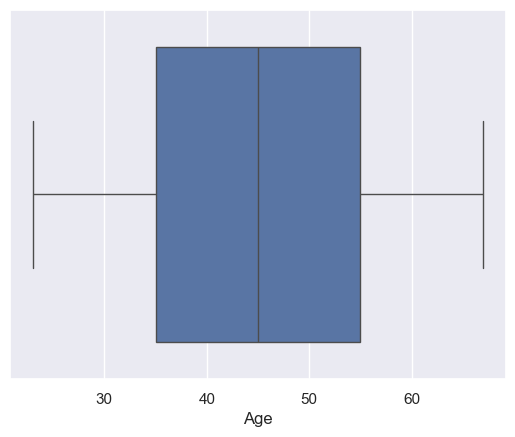

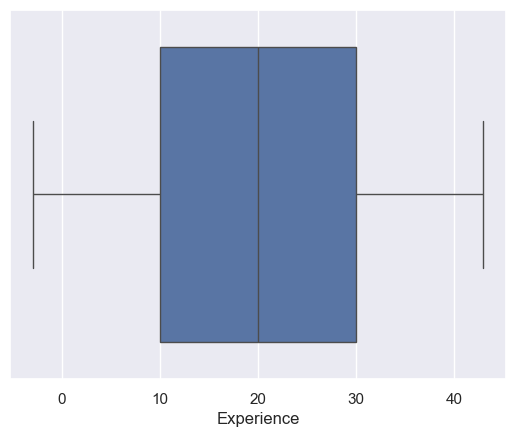

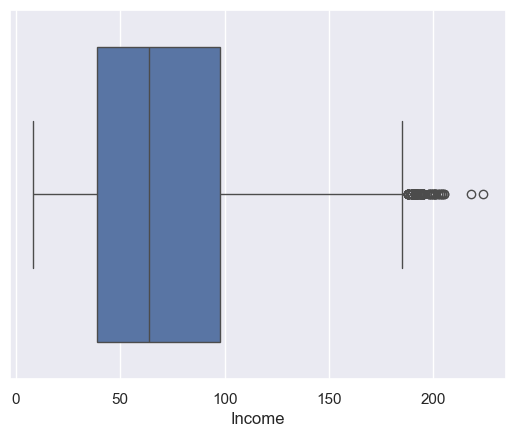

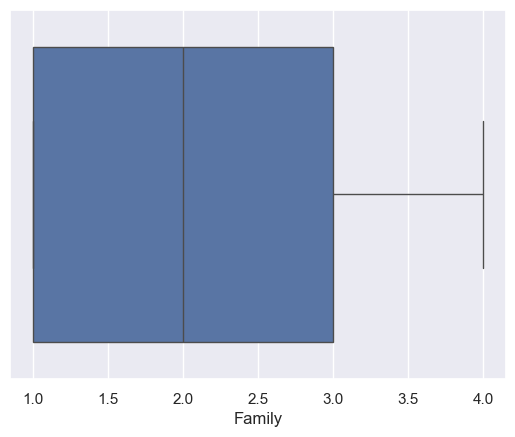

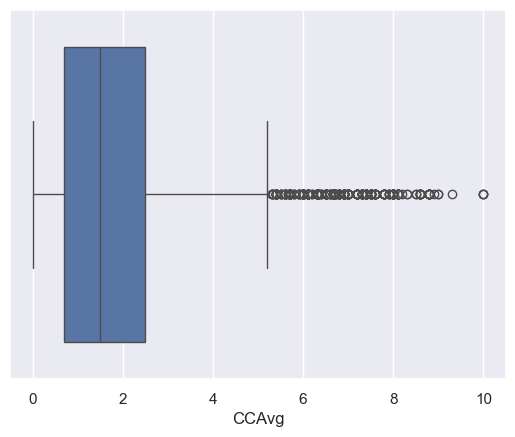

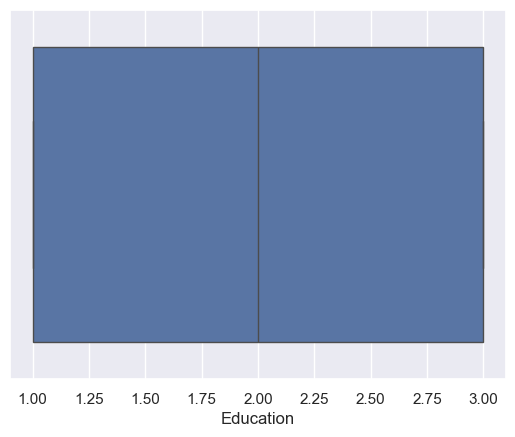

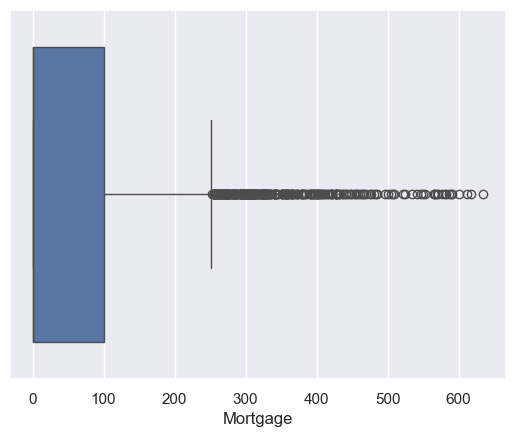

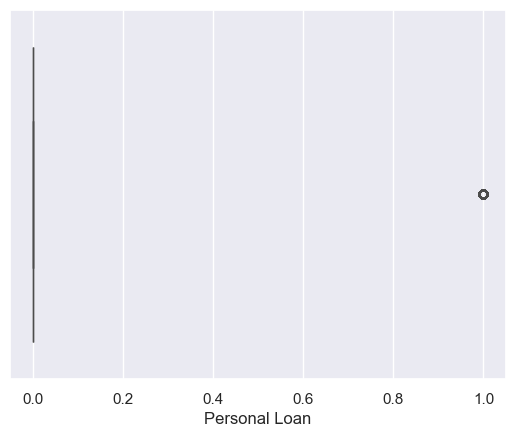

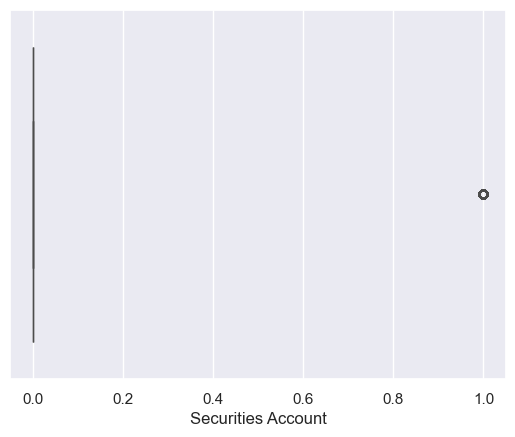

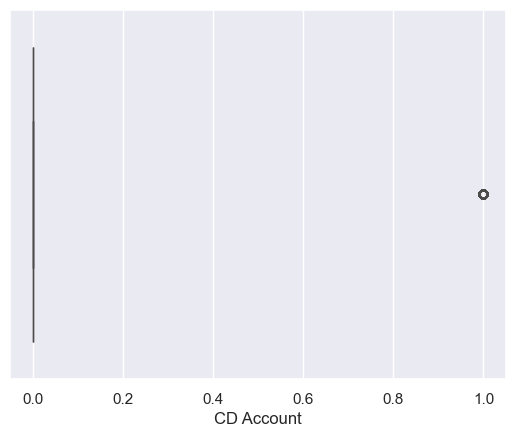

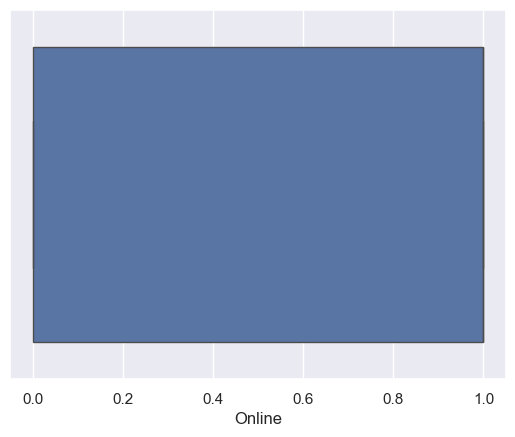

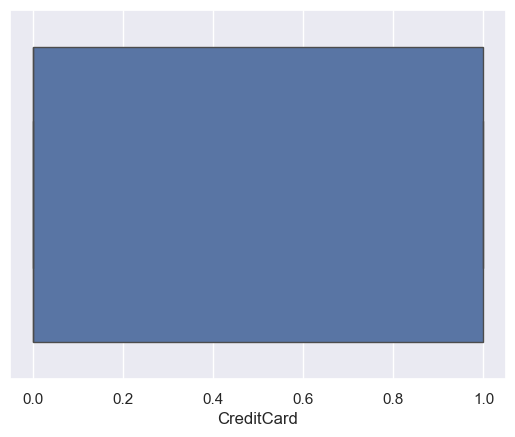

In [11]:
for i in data.columns:
    if data[i].dtypes!=object:
        sns.boxplot(data=data,x=data[i])
        plt.show()

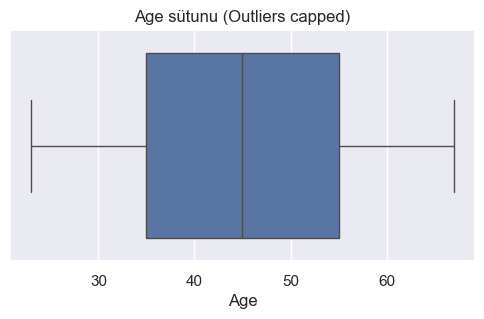

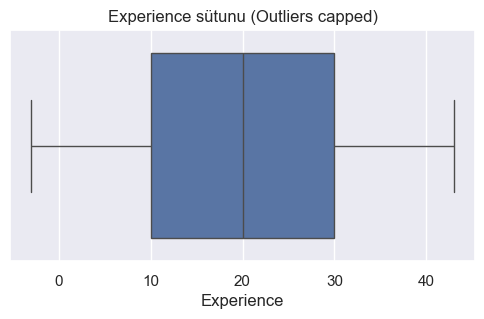

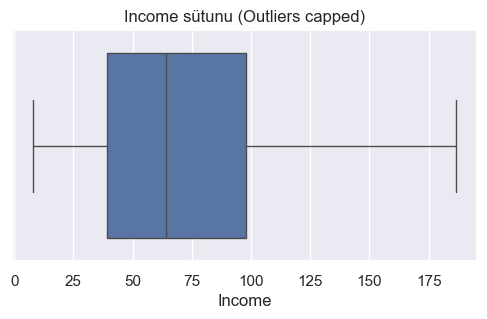

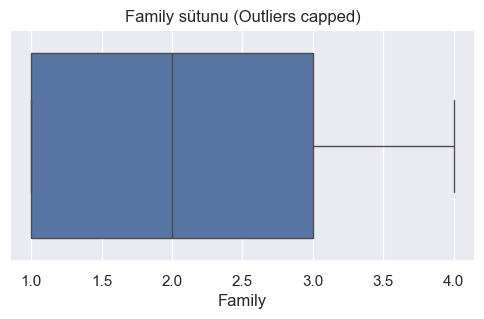

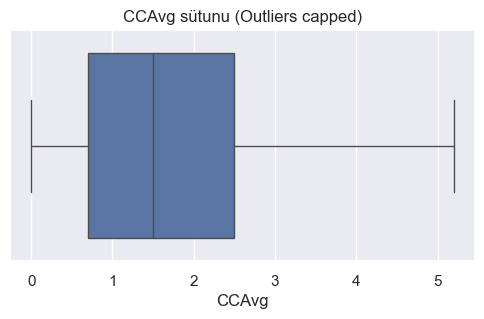

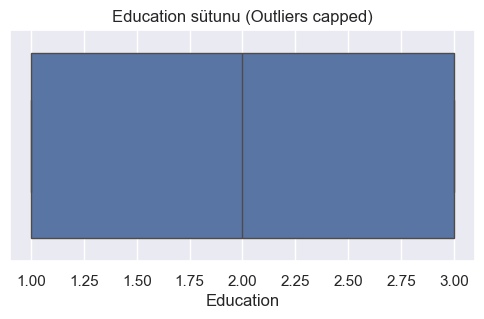

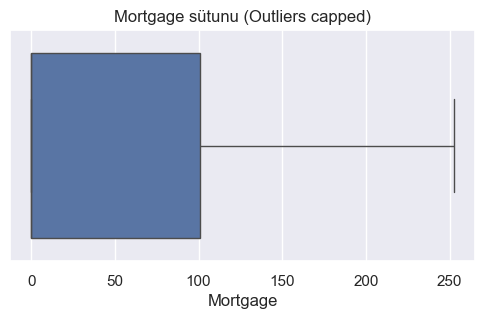

In [12]:
for i in data.columns:
    if data[i].dtype != 'object' and data[i].nunique() > 2:
        
        Q1 = data[i].quantile(0.25)
        Q3 = data[i].quantile(0.75)
        IQR = Q3 - Q1
        
        Lower_Limit = Q1 - 1.5 * IQR
        Upper_Limit = Q3 + 1.5 * IQR
        
        data[i] = np.where(data[i] > Upper_Limit, Upper_Limit, data[i])
        data[i] = np.where(data[i] < Lower_Limit, Lower_Limit, data[i])
        
        plt.figure(figsize=(6, 3)) 
        sns.boxplot(x=data[i])
        plt.title(f'{i} sütunu (Outliers capped)')
        plt.show()

Text(0.5, 1.0, 'Visualization of raw data')

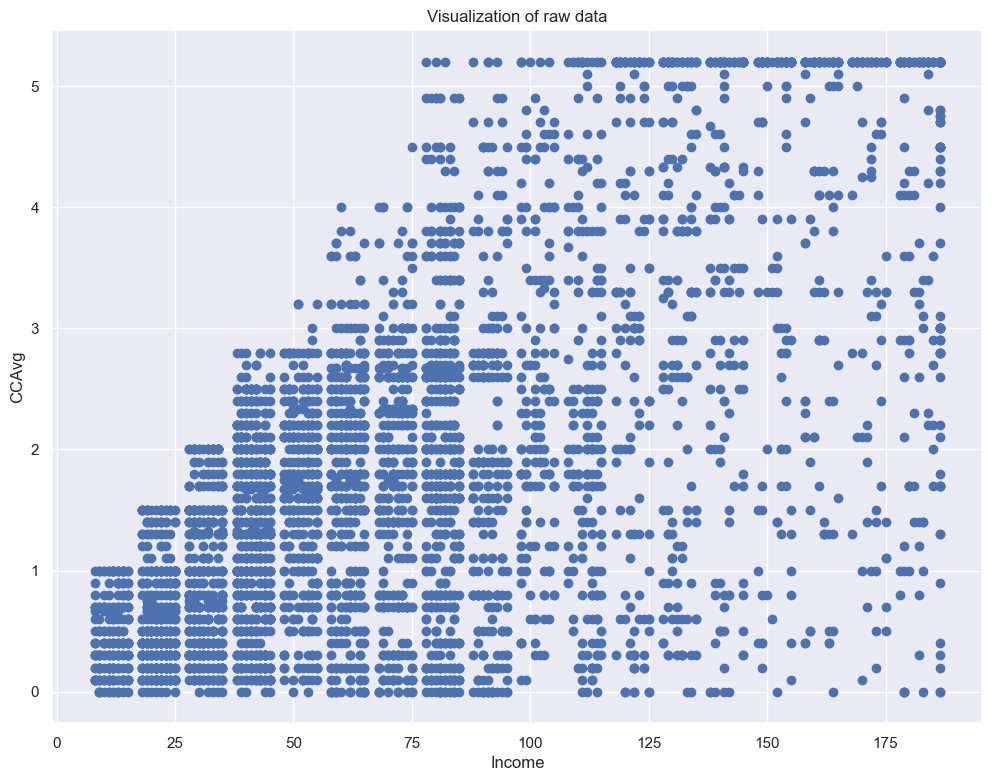

In [13]:
plt.figure(figsize = (12, 9))
plt.scatter(data['Income'], data['CCAvg'])
plt.xlabel('Income')
plt.ylabel('CCAvg')
plt.title('Visualization of raw data')

In [14]:
scaler = StandardScaler()
data_std = scaler.fit_transform(data)

data_scaled = pd.DataFrame(data_std, columns=data.columns)
data_scaled.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,-1.774417,-1.666078,-0.539600,1.397414,-0.159316,-1.049078,-0.608391,-0.325875,2.928915,-0.25354,-1.216618,-0.645314
1,-0.029524,-0.096330,-0.868392,0.525991,-0.228183,-1.049078,-0.608391,-0.325875,2.928915,-0.25354,-1.216618,-0.645314
2,-0.552992,-0.445163,-1.372540,-1.216855,-0.572519,-1.049078,-0.608391,-0.325875,-0.341423,-0.25354,-1.216618,-0.645314
3,-0.901970,-0.968413,0.578292,-1.216855,0.598223,0.141703,-0.608391,-0.325875,-0.341423,-0.25354,-1.216618,-0.645314
4,-0.901970,-1.055621,-0.627278,1.397414,-0.572519,0.141703,-0.608391,-0.325875,-0.341423,-0.25354,-1.216618,1.549632


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []

for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, random_state=42)  
    kmeans.fit(data_scaled)
    
    wcss_iter = kmeans.inertia_
    wcss.append(wcss_iter)
    
    print(f"Cluster {i}: WCSS = {wcss_iter:.4f}")  
    
    if i > 1: 
        y = kmeans.predict(data_scaled)
        silhouette_avg = silhouette_score(data_scaled, y)
        silhouette_scores.append(silhouette_avg)
        print(f"Silhouette Score = {silhouette_avg:.4f}")  
    else:
        print(" (Silhouette Score not applicable for k=1)")  


Cluster 1: WCSS = 60000.0000
 (Silhouette Score not applicable for k=1)
Cluster 2: WCSS = 52444.7627
Silhouette Score = 0.1319
Cluster 3: WCSS = 45643.4781
Silhouette Score = 0.1386
Cluster 4: WCSS = 42705.7024
Silhouette Score = 0.1349
Cluster 5: WCSS = 38949.0349
Silhouette Score = 0.1445
Cluster 6: WCSS = 36118.1278
Silhouette Score = 0.1362
Cluster 7: WCSS = 34334.8819
Silhouette Score = 0.1371


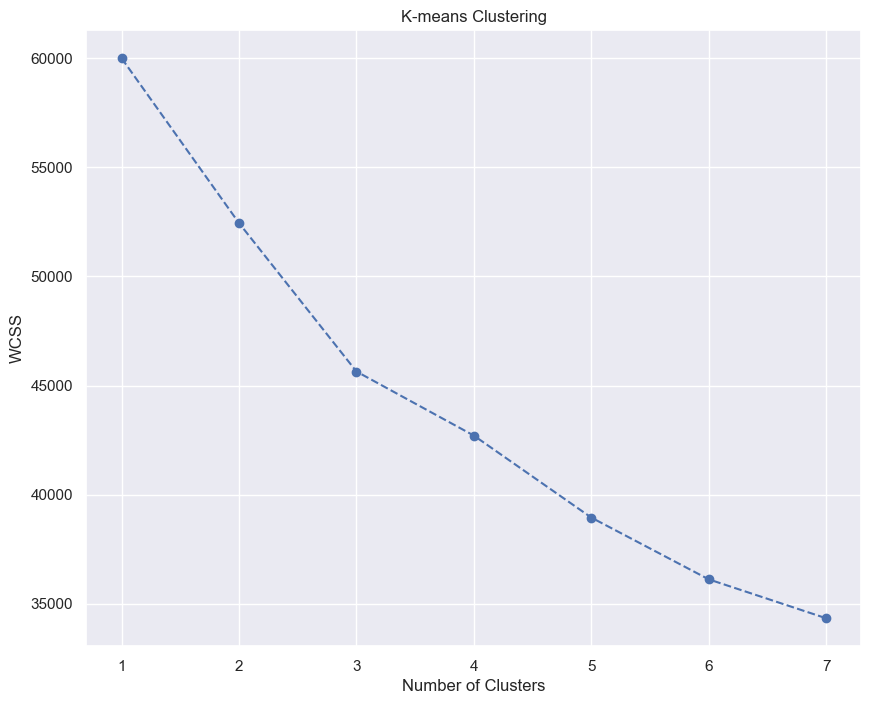

In [16]:
plt.figure(figsize = (10,8))
plt.plot(range(1, 8), wcss, marker = 'o', linestyle = '--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('K-means Clustering')
plt.show()

The optimal number of clusters (elbow point) is: 3


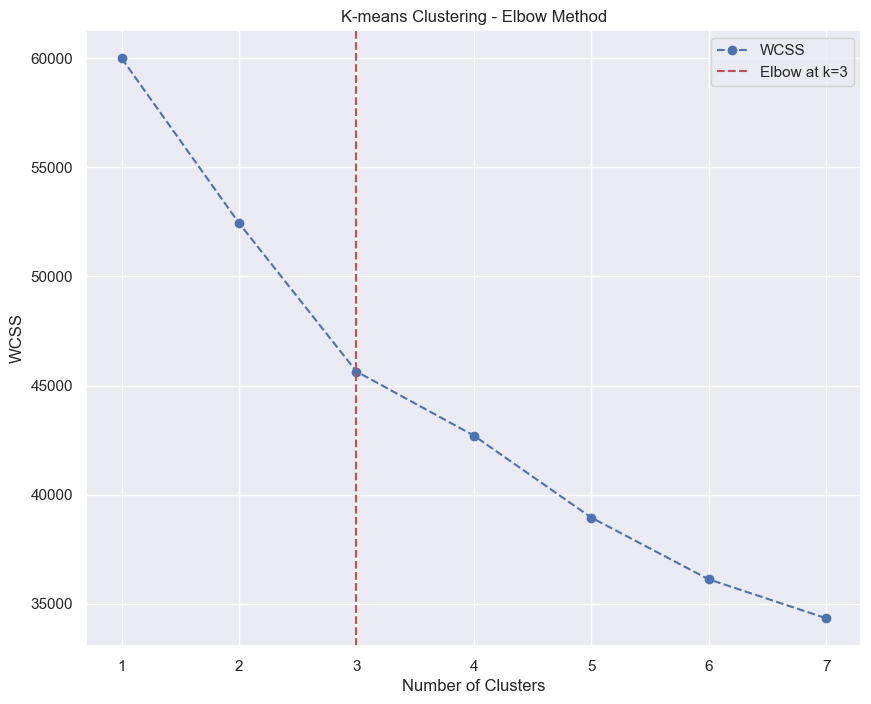

In [56]:
from kneed import KneeLocator

knee_locator = KneeLocator(range(1, 8), wcss, curve="convex", direction="decreasing")


optimal_k = knee_locator.elbow
print(f"The optimal number of clusters (elbow point) is: {optimal_k}")


plt.figure(figsize=(10, 8))
plt.plot(range(1, 8), wcss, marker="o", linestyle="--", label="WCSS")
plt.axvline(optimal_k, linestyle="--", color="r", label=f"Elbow at k={optimal_k}")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("K-means Clustering - Elbow Method")
plt.legend()
plt.show()


In [18]:
kmeans = KMeans(3)
kmeans.fit(data_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [19]:
data['Segments_KM'] = kmeans.predict(data_scaled)
data

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,Segments_KM
0,25.0,1.0,49.0,4.0,1.6,1.0,0.0,0,1,0,0,0,1
1,45.0,19.0,34.0,3.0,1.5,1.0,0.0,0,1,0,0,0,1
2,39.0,15.0,11.0,1.0,1.0,1.0,0.0,0,0,0,0,0,1
3,35.0,9.0,100.0,1.0,2.7,2.0,0.0,0,0,0,0,0,1
4,35.0,8.0,45.0,4.0,1.0,2.0,0.0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29.0,3.0,40.0,1.0,1.9,3.0,0.0,0,0,0,1,0,1
4996,30.0,4.0,15.0,4.0,0.4,1.0,85.0,0,0,0,1,0,1
4997,63.0,39.0,24.0,2.0,0.3,3.0,0.0,0,0,0,0,0,0
4998,65.0,40.0,49.0,3.0,0.5,2.0,0.0,0,0,0,1,0,0


In [20]:
df_segm_analysis = data.groupby(['Segments_KM'], as_index=False).mean()
df_segm_analysis

,Segments_KM,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,0,55.428165,30.117117,57.067330,2.366050,1.350213,1.925083,46.248696,0.000000,0.095306,0.030346,0.609294,0.298246
1,1,35.251512,9.997480,58.838458,2.571069,1.389506,1.927419,46.154486,0.000000,0.103831,0.026714,0.575605,0.278226
2,2,43.941566,18.931643,144.428335,2.084895,3.916549,1.676957,69.861632,0.529217,0.126792,0.203969,0.614112,0.318633


In [21]:
df_segm_analysis['data count'] = data[['Segments_KM','Age']].groupby(['Segments_KM']).count()
df_segm_analysis['data proportion'] = df_segm_analysis['data count'] / df_segm_analysis['data count'].sum()

df_segm_analysis
#2

,Segments_KM,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,data count,data proportion
0,0,55.428165,30.117117,57.067330,2.366050,1.350213,1.925083,46.248696,0.000000,0.095306,0.030346,0.609294,0.298246,2109,0.4218
1,1,35.251512,9.997480,58.838458,2.571069,1.389506,1.927419,46.154486,0.000000,0.103831,0.026714,0.575605,0.278226,1984,0.3968
2,2,43.941566,18.931643,144.428335,2.084895,3.916549,1.676957,69.861632,0.529217,0.126792,0.203969,0.614112,0.318633,907,0.1814


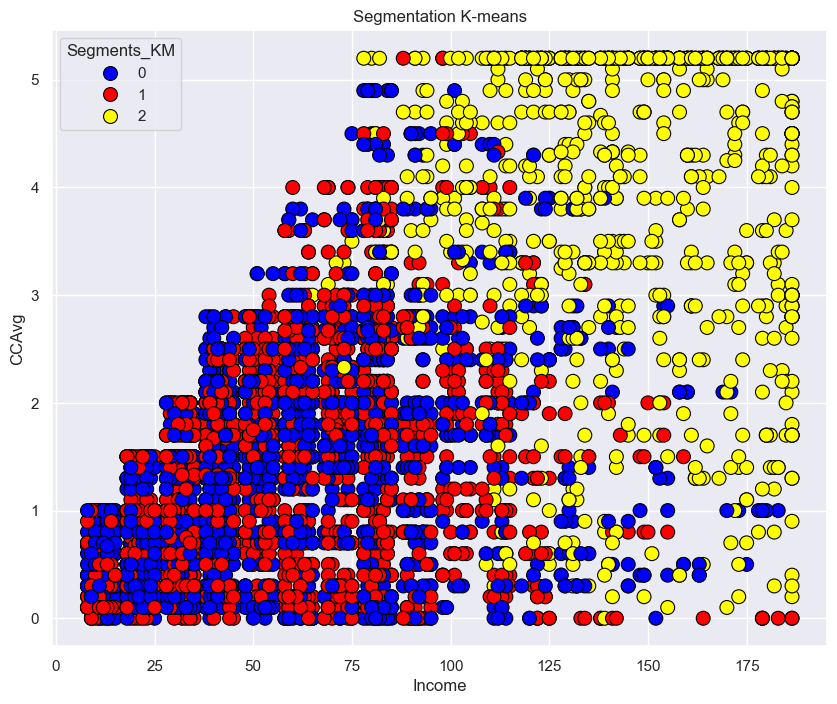

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.scatterplot(x=data['Income'], y=data['CCAvg'], hue=data['Segments_KM'], palette=['blue', 'red', 'yellow'], s=100, edgecolor="black")

plt.title('Segmentation K-means')
plt.xlabel("Income")
plt.ylabel("CCAvg")
plt.legend(title="Segments_KM")
plt.show()


In [23]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(data_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [24]:
pca.explained_variance_ratio_

array([0.18615551, 0.1650316 , 0.1178042 , 0.09537278, 0.08469009,
       0.08238042, 0.08131232, 0.07731595, 0.04770494, 0.03636492,
       0.02542186, 0.00044543])

Text(0, 0.5, 'Cumulative Explained Variance')

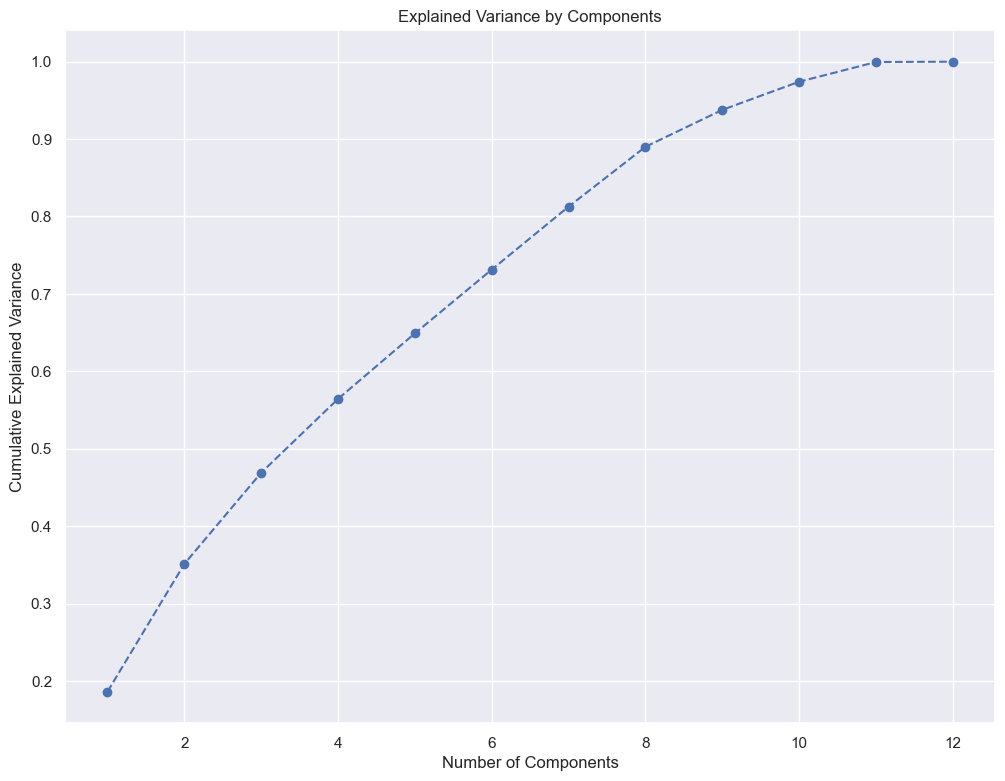

In [25]:
plt.figure(figsize = (12,9))
plt.plot(range(1,13), pca.explained_variance_ratio_.cumsum(), marker = 'o', linestyle = '--')
plt.title('Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

In [26]:
pca = PCA(n_components = 7)

In [27]:
pca.fit(data_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",7
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [28]:
pca.components_

array([[-0.22727955, -0.22290554,  0.5465951 , -0.07177212,  0.50296569,
        -0.09879749,  0.14448614,  0.45707137,  0.09079009,  0.29716118,
         0.0451923 ,  0.06019811],
       [ 0.66472647,  0.66593223,  0.15395293, -0.0905572 ,  0.13334282,
         0.0078175 ,  0.04272137,  0.1731809 ,  0.05382081,  0.15786079,
         0.04937569,  0.05346066],
       [-0.04690834, -0.05342778, -0.2463985 ,  0.270325  , -0.235355  ,
         0.23227338, -0.03705895,  0.06678008,  0.44106661,  0.5820651 ,
         0.25534001,  0.38398353],
       [ 0.02270338,  0.00305056, -0.0264615 ,  0.43536153, -0.01055164,
         0.68153705,  0.0682201 ,  0.42621605, -0.20444564, -0.1283961 ,
        -0.20547107, -0.24044801],
       [-0.00689725, -0.00609601,  0.00478733, -0.0191697 , -0.03058937,
         0.03463369,  0.131271  ,  0.0086105 , -0.60340514,  0.01821594,
        -0.1712489 ,  0.76572037],
       [-0.00590494, -0.00661889,  0.03116415,  0.09257255,  0.0075515 ,
         0.01848068, -

In [29]:
df_pca_comp = pd.DataFrame(data = pca.components_,
                           columns = data.columns[:-1].values,
                           index = ['Component 1', 'Component 2', 'Component 3','Component 4','Component 5','Component 6','Component 7'])
df_pca_comp
#Component 1

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
Component 1,-0.227280,-0.222906,0.546595,-0.071772,0.502966,-0.098797,0.144486,0.457071,0.090790,0.297161,0.045192,0.060198
Component 2,0.664726,0.665932,0.153953,-0.090557,0.133343,0.007817,0.042721,0.173181,0.053821,0.157861,0.049376,0.053461
Component 3,-0.046908,-0.053428,-0.246399,0.270325,-0.235355,0.232273,-0.037059,0.066780,0.441067,0.582065,0.255340,0.383984
Component 4,0.022703,0.003051,-0.026462,0.435362,-0.010552,0.681537,0.068220,0.426216,-0.204446,-0.128396,-0.205471,-0.240448
Component 5,-0.006897,-0.006096,0.004787,-0.019170,-0.030589,0.034634,0.131271,0.008611,-0.603405,0.018216,-0.171249,0.765720
Component 6,-0.005905,-0.006619,0.031164,0.092573,0.007551,0.018481,-0.128109,0.043337,-0.426119,-0.035894,0.880679,-0.115021
Component 7,0.008435,0.012204,-0.049362,0.141731,-0.139365,-0.138878,0.949146,-0.086816,0.008264,0.006376,0.121583,-0.123444


In [30]:
data_scaled

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,-1.774417,-1.666078,-0.539600,1.397414,-0.159316,-1.049078,-0.608391,-0.325875,2.928915,-0.25354,-1.216618,-0.645314
1,-0.029524,-0.096330,-0.868392,0.525991,-0.228183,-1.049078,-0.608391,-0.325875,2.928915,-0.25354,-1.216618,-0.645314
2,-0.552992,-0.445163,-1.372540,-1.216855,-0.572519,-1.049078,-0.608391,-0.325875,-0.341423,-0.25354,-1.216618,-0.645314
3,-0.901970,-0.968413,0.578292,-1.216855,0.598223,0.141703,-0.608391,-0.325875,-0.341423,-0.25354,-1.216618,-0.645314
4,-0.901970,-1.055621,-0.627278,1.397414,-0.572519,0.141703,-0.608391,-0.325875,-0.341423,-0.25354,-1.216618,1.549632
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.425438,-1.491662,-0.736875,-1.216855,0.047286,1.332484,-0.608391,-0.325875,-0.341423,-0.25354,0.821951,-0.645314
4996,-1.338194,-1.404454,-1.284862,1.397414,-0.985723,-1.049078,0.415741,-0.325875,-0.341423,-0.25354,0.821951,-0.645314
4997,1.540880,1.647835,-1.087587,-0.345432,-1.054590,1.332484,-0.608391,-0.325875,-0.341423,-0.25354,-1.216618,-0.645314
4998,1.715370,1.735043,-0.539600,0.525991,-0.916855,0.141703,-0.608391,-0.325875,-0.341423,-0.25354,0.821951,-0.645314


In [31]:
scores_pca = pca.transform(data_scaled)

scores_pca

array([[ 0.26283773, -2.58744535,  1.06339822, ..., -2.17883317,
        -2.05891287, -0.23754358],
       [-0.63545643, -0.36311046,  0.75933465, ..., -2.18319986,
        -2.17104278, -0.30134835],
       [-1.05930648, -1.08508734, -0.90578253, ..., -0.16259446,
        -0.95173981, -0.51118874],
       ...,
       [-2.38628872,  1.61985228, -0.28384029, ..., -0.10790762,
        -0.84803465, -0.62210362],
       [-1.92935345,  1.90907793,  0.0153847 , ..., -0.51828124,
         1.02246378, -0.12907626],
       [ 0.26517578, -2.0770675 ,  0.66852423, ...,  1.15984414,
         0.8126185 , -0.36578181]], shape=(5000, 7))

In [32]:
scores_pca.shape

(5000, 7)

In [33]:
pca_df = pd.DataFrame(scores_pca, columns=[f'Variable_{i+1}' for i in range(scores_pca.shape[1])])

pca_df

,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7
0,0.262838,-2.587445,1.063398,-0.477517,-2.178833,-2.058913,-0.237544
1,-0.635456,-0.363110,0.759335,-0.803071,-2.183200,-2.171043,-0.301348
2,-1.059306,-1.085087,-0.905783,-0.889207,-0.162594,-0.951740,-0.511189
3,0.674157,-1.199756,-1.341092,-0.151140,-0.142230,-0.854572,-0.945349
4,-0.609706,-1.718940,0.785684,0.503230,1.518943,-0.910863,-0.624173
...,...,...,...,...,...,...,...
4995,-0.111720,-2.062141,-0.037745,0.268688,-0.432734,0.924167,-0.731966
4996,-0.774449,-2.379787,0.447226,-0.118769,-0.403050,0.964992,1.114170
4997,-2.386289,1.619852,-0.283840,1.164769,-0.107908,-0.848035,-0.622104
4998,-1.929353,1.909078,0.015385,0.301998,-0.518281,1.022464,-0.129076


In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss_pca = []
silhouette_scores_pca = []

for i in range(1, 8):
    kmeans_pca = KMeans(n_clusters=i, random_state=42)  
    kmeans_pca.fit(pca_df)
    
    wcss_iter = kmeans_pca.inertia_
    wcss_pca.append(wcss_iter)
    
    print(f"Cluster {i}: WCSS = {wcss_iter:.4f}")  
    
    if i > 1:  
        y = kmeans_pca.predict(pca_df)
        silhouette_avg = silhouette_score(pca_df, y)
        silhouette_scores_pca.append(silhouette_avg)
        print(f"Silhouette Score = {silhouette_avg:.4f}")  
    else:
        print(" (Silhouette Score not applicable for k=1)")  


Cluster 1: WCSS = 48764.8141
 (Silhouette Score not applicable for k=1)
Cluster 2: WCSS = 40670.2820
Silhouette Score = 0.2700
Cluster 3: WCSS = 34434.3690
Silhouette Score = 0.1793
Cluster 4: WCSS = 30363.5413
Silhouette Score = 0.1963
Cluster 5: WCSS = 27911.9988
Silhouette Score = 0.1991
Cluster 6: WCSS = 25932.8184
Silhouette Score = 0.1817
Cluster 7: WCSS = 24732.2176
Silhouette Score = 0.1889


The optimal number of clusters (elbow point) is: 4


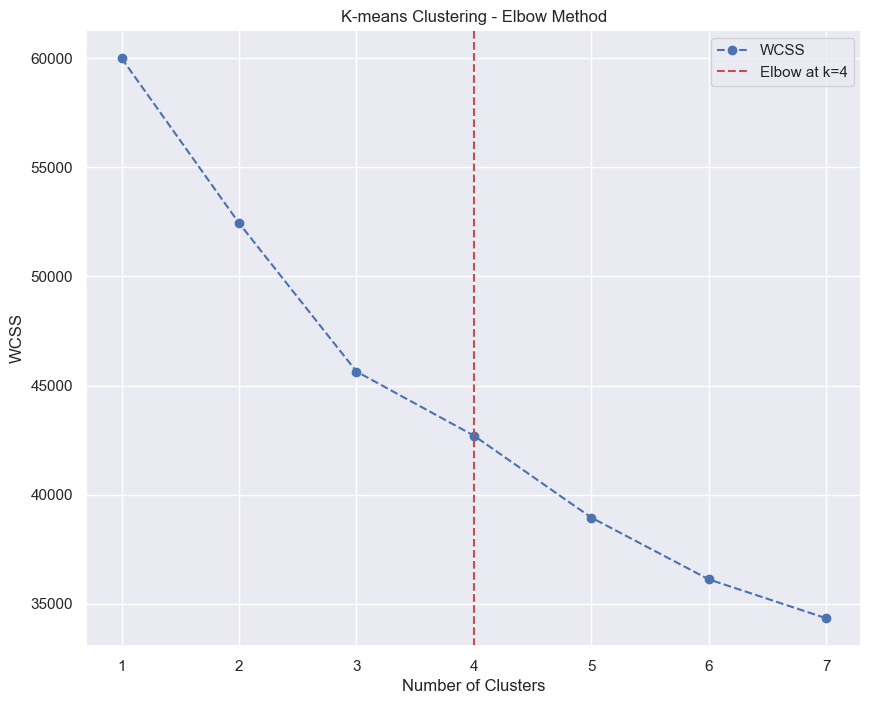

In [35]:
from kneed import KneeLocator

knee_locator = KneeLocator(range(1, 8), wcss_pca, curve="convex", direction="decreasing")

optimal_k = knee_locator.elbow
print(f"The optimal number of clusters (elbow point) is: {optimal_k}")

plt.figure(figsize=(10, 8))
plt.plot(range(1, 8), wcss, marker="o", linestyle="--", label="WCSS")
plt.axvline(optimal_k, linestyle="--", color="r", label=f"Elbow at k={optimal_k}")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("K-means Clustering - Elbow Method")
plt.legend()
plt.show()


In [36]:
kmeans_pca = KMeans(4)
kmeans_pca.fit(pca_df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [37]:
data['Segment_KM_PCA'] = kmeans_pca.predict(pca_df)
data

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,Segments_KM,Segment_KM_PCA
0,25.0,1.0,49.0,4.0,1.6,1.0,0.0,0,1,0,0,0,1,2
1,45.0,19.0,34.0,3.0,1.5,1.0,0.0,0,1,0,0,0,1,2
2,39.0,15.0,11.0,1.0,1.0,1.0,0.0,0,0,0,0,0,1,2
3,35.0,9.0,100.0,1.0,2.7,2.0,0.0,0,0,0,0,0,1,2
4,35.0,8.0,45.0,4.0,1.0,2.0,0.0,0,0,0,0,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29.0,3.0,40.0,1.0,1.9,3.0,0.0,0,0,0,1,0,1,0
4996,30.0,4.0,15.0,4.0,0.4,1.0,85.0,0,0,0,1,0,1,0
4997,63.0,39.0,24.0,2.0,0.3,3.0,0.0,0,0,0,0,0,0,1
4998,65.0,40.0,49.0,3.0,0.5,2.0,0.0,0,0,0,1,0,0,1


In [38]:
data = pd.concat([data,pca_df], axis=1)

data

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,...,CreditCard,Segments_KM,Segment_KM_PCA,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7
0,25.0,1.0,49.0,4.0,1.6,1.0,0.0,0,1,0,...,0,1,2,0.262838,-2.587445,1.063398,-0.477517,-2.178833,-2.058913,-0.237544
1,45.0,19.0,34.0,3.0,1.5,1.0,0.0,0,1,0,...,0,1,2,-0.635456,-0.363110,0.759335,-0.803071,-2.183200,-2.171043,-0.301348
2,39.0,15.0,11.0,1.0,1.0,1.0,0.0,0,0,0,...,0,1,2,-1.059306,-1.085087,-0.905783,-0.889207,-0.162594,-0.951740,-0.511189
3,35.0,9.0,100.0,1.0,2.7,2.0,0.0,0,0,0,...,0,1,2,0.674157,-1.199756,-1.341092,-0.151140,-0.142230,-0.854572,-0.945349
4,35.0,8.0,45.0,4.0,1.0,2.0,0.0,0,0,0,...,1,1,2,-0.609706,-1.718940,0.785684,0.503230,1.518943,-0.910863,-0.624173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29.0,3.0,40.0,1.0,1.9,3.0,0.0,0,0,0,...,0,1,0,-0.111720,-2.062141,-0.037745,0.268688,-0.432734,0.924167,-0.731966
4996,30.0,4.0,15.0,4.0,0.4,1.0,85.0,0,0,0,...,0,1,0,-0.774449,-2.379787,0.447226,-0.118769,-0.403050,0.964992,1.114170
4997,63.0,39.0,24.0,2.0,0.3,3.0,0.0,0,0,0,...,0,0,1,-2.386289,1.619852,-0.283840,1.164769,-0.107908,-0.848035,-0.622104
4998,65.0,40.0,49.0,3.0,0.5,2.0,0.0,0,0,0,...,0,0,1,-1.929353,1.909078,0.015385,0.301998,-0.518281,1.022464,-0.129076


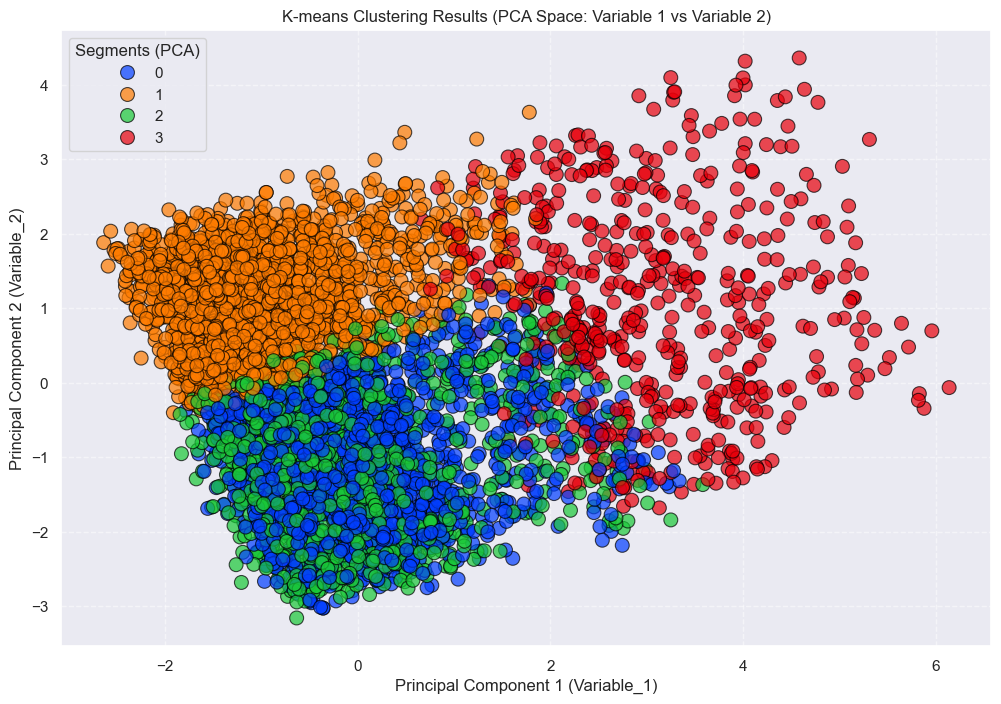

In [39]:
plt.figure(figsize=(12, 8))

sns.scatterplot(x=pca_df['Variable_1'], 
                y=pca_df['Variable_2'], 
                hue=data['Segment_KM_PCA'], 
                palette='bright', 
                s=100, 
                edgecolor="black",
                alpha=0.7)

plt.title('K-means Clustering Results (PCA Space: Variable 1 vs Variable 2)')
plt.xlabel("Principal Component 1 (Variable_1)")
plt.ylabel("Principal Component 2 (Variable_2)")
plt.legend(title="Segments (PCA)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

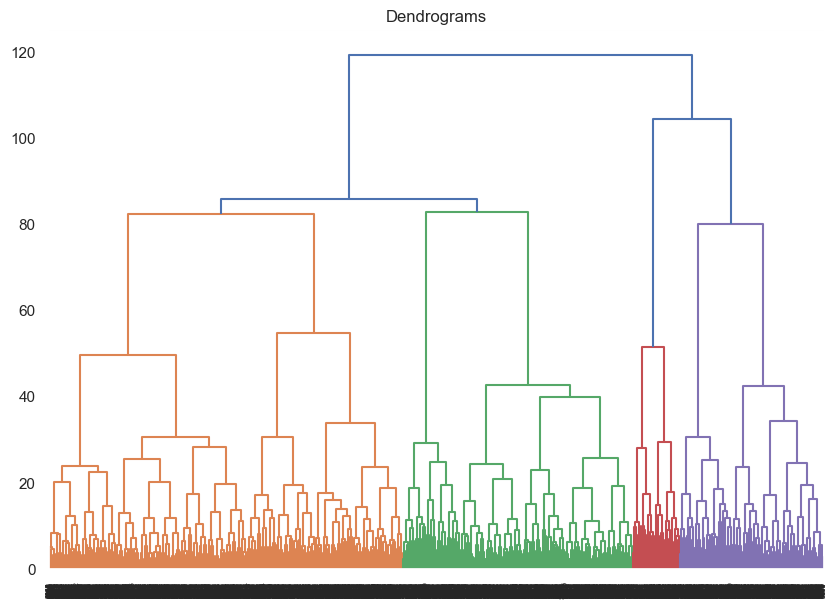

In [40]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10, 7))  
plt.title("Dendrograms")  

dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))

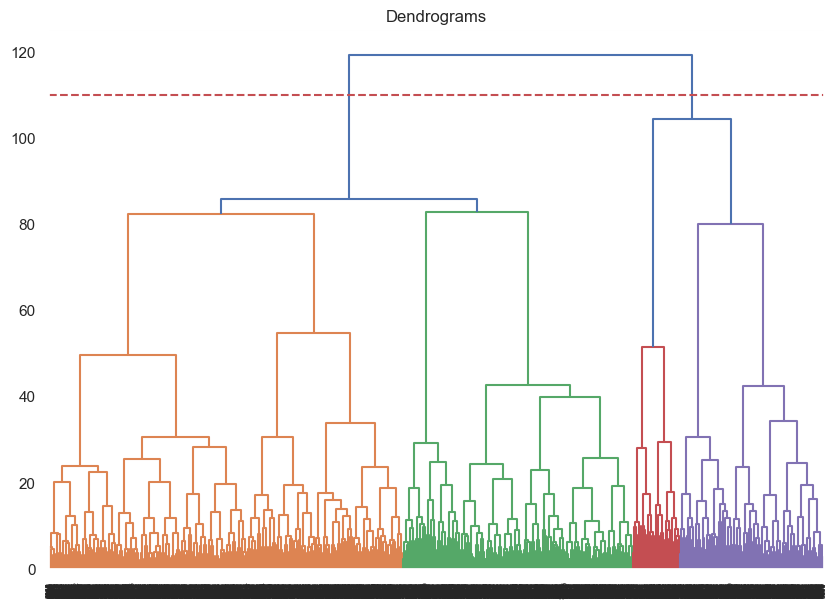

In [41]:
plt.figure(figsize=(10, 7))  
plt.title("Dendrograms")  

shc.dendrogram(shc.linkage(data_scaled, method='ward'))

plt.axhline(y=110, color='r', linestyle='--') 
plt.show() 

In [42]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=2,linkage='ward')  
y = cluster.fit_predict(data_scaled)
y

array([1, 1, 1, ..., 1, 1, 1], shape=(5000,))

In [43]:
data['segment_HC'] = y

data

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,...,Segments_KM,Segment_KM_PCA,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,segment_HC
0,25.0,1.0,49.0,4.0,1.6,1.0,0.0,0,1,0,...,1,2,0.262838,-2.587445,1.063398,-0.477517,-2.178833,-2.058913,-0.237544,1
1,45.0,19.0,34.0,3.0,1.5,1.0,0.0,0,1,0,...,1,2,-0.635456,-0.363110,0.759335,-0.803071,-2.183200,-2.171043,-0.301348,1
2,39.0,15.0,11.0,1.0,1.0,1.0,0.0,0,0,0,...,1,2,-1.059306,-1.085087,-0.905783,-0.889207,-0.162594,-0.951740,-0.511189,1
3,35.0,9.0,100.0,1.0,2.7,2.0,0.0,0,0,0,...,1,2,0.674157,-1.199756,-1.341092,-0.151140,-0.142230,-0.854572,-0.945349,1
4,35.0,8.0,45.0,4.0,1.0,2.0,0.0,0,0,0,...,1,2,-0.609706,-1.718940,0.785684,0.503230,1.518943,-0.910863,-0.624173,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29.0,3.0,40.0,1.0,1.9,3.0,0.0,0,0,0,...,1,0,-0.111720,-2.062141,-0.037745,0.268688,-0.432734,0.924167,-0.731966,1
4996,30.0,4.0,15.0,4.0,0.4,1.0,85.0,0,0,0,...,1,0,-0.774449,-2.379787,0.447226,-0.118769,-0.403050,0.964992,1.114170,1
4997,63.0,39.0,24.0,2.0,0.3,3.0,0.0,0,0,0,...,0,1,-2.386289,1.619852,-0.283840,1.164769,-0.107908,-0.848035,-0.622104,1
4998,65.0,40.0,49.0,3.0,0.5,2.0,0.0,0,0,0,...,0,1,-1.929353,1.909078,0.015385,0.301998,-0.518281,1.022464,-0.129076,1


In [45]:
analysis = data.groupby('segment_HC',as_index=False).mean()
analysis


,segment_HC,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,...,CreditCard,Segments_KM,Segment_KM_PCA,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7
0,0,45.739414,20.692182,129.436482,2.038274,3.244894,1.585505,70.185668,0.390879,0.127036,...,0.339577,1.496743,1.816775,1.936139,0.721175,-0.096115,-0.131863,0.040100,0.029199,-0.048274
1,1,45.207847,19.913309,55.445122,2.512990,1.371145,1.977200,44.084173,0.000000,0.097031,...,0.279162,0.519618,0.943531,-0.630323,-0.234783,0.031291,0.042929,-0.013055,-0.009506,0.015716


In [48]:
analysis['data count'] = data[['segment_HC','Age']].groupby(['segment_HC']).count()
analysis['data proportion'] = analysis['data count'] / analysis['data count'].sum()

analysis
#0

,segment_HC,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,...,Segment_KM_PCA,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,data count,data proportion
0,0,45.739414,20.692182,129.436482,2.038274,3.244894,1.585505,70.185668,0.390879,0.127036,...,1.816775,1.936139,0.721175,-0.096115,-0.131863,0.040100,0.029199,-0.048274,1228,0.2456
1,1,45.207847,19.913309,55.445122,2.512990,1.371145,1.977200,44.084173,0.000000,0.097031,...,0.943531,-0.630323,-0.234783,0.031291,0.042929,-0.013055,-0.009506,0.015716,3772,0.7544


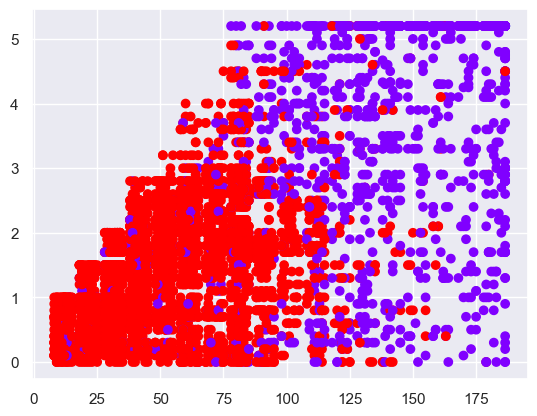

In [49]:
plt.scatter(data['Income'],data['CCAvg'],c=data['segment_HC'],cmap='rainbow')
plt.xlim()
plt.ylim()
plt.show()

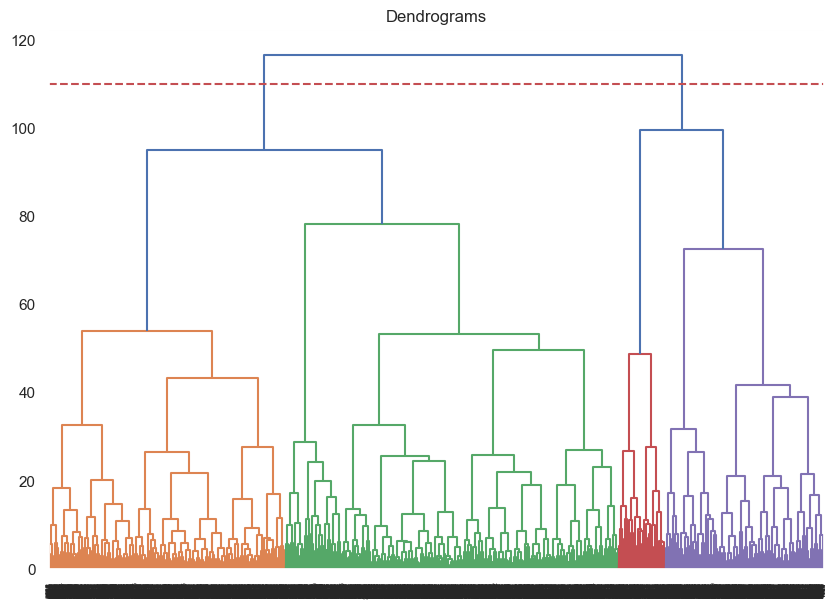

In [50]:
plt.figure(figsize=(10, 7))  
plt.title("Dendrograms")  

shc.dendrogram(shc.linkage(pca_df, method='ward'))

plt.axhline(y=110, color='r', linestyle='--') 
plt.show() 

In [51]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=2,linkage='ward')  
y = cluster.fit_predict(pca_df)
y

array([1, 1, 1, ..., 1, 1, 1], shape=(5000,))

In [52]:
data['segment_HC_PCA'] = y

data

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,...,Segment_KM_PCA,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,segment_HC,segment_HC_PCA
0,25.0,1.0,49.0,4.0,1.6,1.0,0.0,0,1,0,...,2,0.262838,-2.587445,1.063398,-0.477517,-2.178833,-2.058913,-0.237544,1,1
1,45.0,19.0,34.0,3.0,1.5,1.0,0.0,0,1,0,...,2,-0.635456,-0.363110,0.759335,-0.803071,-2.183200,-2.171043,-0.301348,1,1
2,39.0,15.0,11.0,1.0,1.0,1.0,0.0,0,0,0,...,2,-1.059306,-1.085087,-0.905783,-0.889207,-0.162594,-0.951740,-0.511189,1,1
3,35.0,9.0,100.0,1.0,2.7,2.0,0.0,0,0,0,...,2,0.674157,-1.199756,-1.341092,-0.151140,-0.142230,-0.854572,-0.945349,1,1
4,35.0,8.0,45.0,4.0,1.0,2.0,0.0,0,0,0,...,2,-0.609706,-1.718940,0.785684,0.503230,1.518943,-0.910863,-0.624173,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29.0,3.0,40.0,1.0,1.9,3.0,0.0,0,0,0,...,0,-0.111720,-2.062141,-0.037745,0.268688,-0.432734,0.924167,-0.731966,1,1
4996,30.0,4.0,15.0,4.0,0.4,1.0,85.0,0,0,0,...,0,-0.774449,-2.379787,0.447226,-0.118769,-0.403050,0.964992,1.114170,1,1
4997,63.0,39.0,24.0,2.0,0.3,3.0,0.0,0,0,0,...,1,-2.386289,1.619852,-0.283840,1.164769,-0.107908,-0.848035,-0.622104,1,1
4998,65.0,40.0,49.0,3.0,0.5,2.0,0.0,0,0,0,...,1,-1.929353,1.909078,0.015385,0.301998,-0.518281,1.022464,-0.129076,1,1


In [53]:
analysis = data.groupby('segment_HC_PCA',as_index=False).mean()
analysis

,segment_HC_PCA,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,...,Segments_KM,Segment_KM_PCA,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,segment_HC
0,0,45.795764,20.692890,125.272315,2.034039,3.238275,1.588502,64.883888,0.362330,0.118003,...,1.416036,1.754160,1.803922,0.676832,-0.138022,-0.155599,0.033870,0.050964,-0.094474,0.131619
1,1,45.174008,19.893148,55.050843,2.526645,1.325636,1.986134,45.322730,0.000272,0.099511,...,0.523654,0.943719,-0.648392,-0.243277,0.049610,0.055928,-0.012174,-0.018318,0.033957,0.978249


In [54]:
analysis['data count'] = data[['segment_HC_PCA','Age']].groupby(['segment_HC_PCA']).count()
analysis['data proportion'] = analysis['data count'] / analysis['data count'].sum()

analysis
#0

,segment_HC_PCA,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,...,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,segment_HC,data count,data proportion
0,0,45.795764,20.692890,125.272315,2.034039,3.238275,1.588502,64.883888,0.362330,0.118003,...,1.803922,0.676832,-0.138022,-0.155599,0.033870,0.050964,-0.094474,0.131619,1322,0.2644
1,1,45.174008,19.893148,55.050843,2.526645,1.325636,1.986134,45.322730,0.000272,0.099511,...,-0.648392,-0.243277,0.049610,0.055928,-0.012174,-0.018318,0.033957,0.978249,3678,0.7356


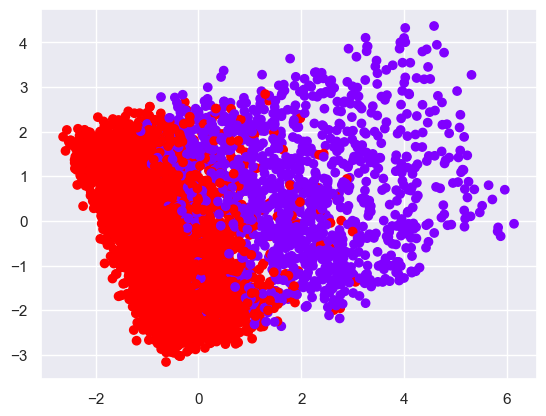

In [55]:
plt.scatter(data['Variable_1'],data['Variable_2'],c=data['segment_HC_PCA'],cmap='rainbow')
plt.xlim()
plt.ylim()
plt.show()